# Materi Pertemuan 4

## 1. Pembuatan Graph

umumnya graph(adjacency list) dibuat menggunakan Dictionary Of List atau Dictionary of Dictionary

### 1.1 Graph Tanpa Atribut (Dictionary of List)

![WhatsApp Image 2026-05-13 at 01.37.59.jpeg](<attachment:WhatsApp Image 2026-05-13 at 01.37.59.jpeg>)
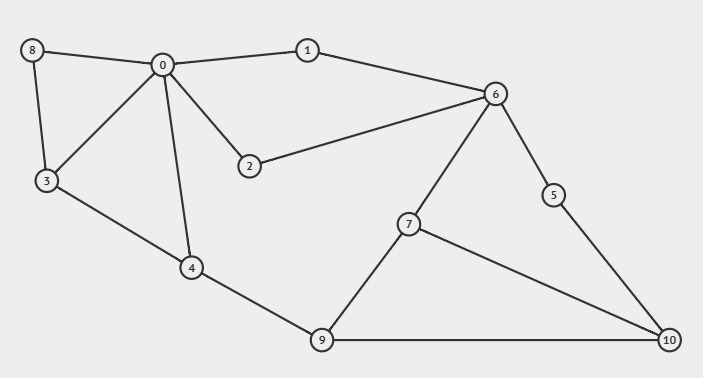

misalnya jika kita ingin membuat Graph Seperti pada gambar diatas, kita dapat menggunakan Struktur Dictionary Of List

untuk key dari dictionary sendiri adalah node nya, sementara value nya berupa list yang berisi tetangga tetangga dari node yang dicantumkan sebagai key

In [113]:
adjlist1 = {
    8 : [0,3],
    0 : [8,3,4,2,1],
    3 : [8,0,4],
    4 : [3,0,9],
    2 : [0,6],
    1 : [0,6],
    6 : [1,2,5],
    7 : [6,10,9],
    9 : [4,7,10],
    5 : [6,10],
    10 : [5,7,9]
}

### 1.2 Graph Dengan Atribut (Dictionary of Dictionary)

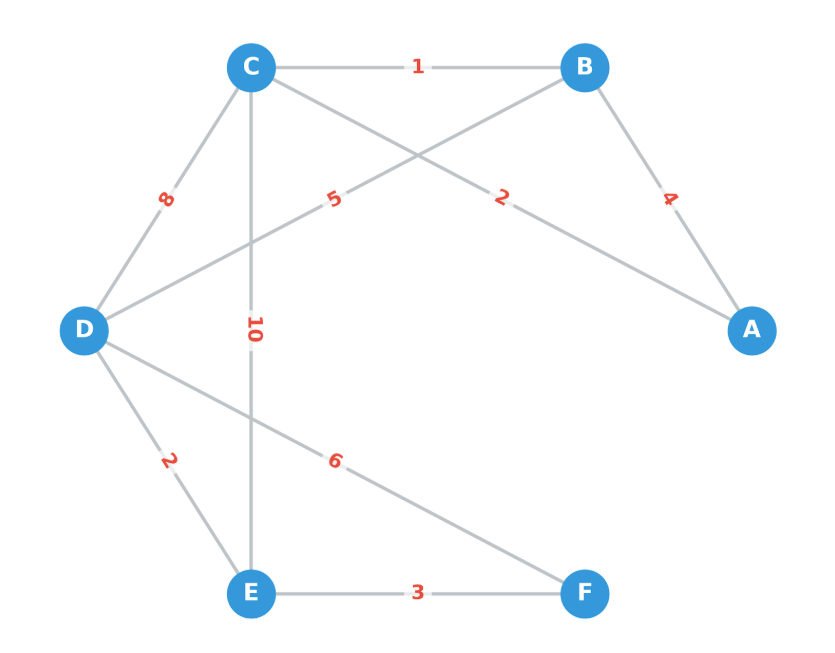

jika kita ingin membuat graph dengan setiap edge memiliki atribut seperti jarak dll, kita dapat menggunakan Struktur Dictionary of Dictionary

untuk key dari dictionary yang pertama adalah node nya dengan value dictionary dari tetangga2 nya, lalu setiap tetangga memiliki value berupa dictionary lagi yang memetakan atributnya

In [114]:
adjlist2 = {
    "A" : {
        "B" : {"Jarak" : 4},
        "C" : {"Jarak" : 2}
    },
    "B" : {
        "A" : {"Jarak" : 4},
        "C" : {"Jarak" : 1},
        "D" : {"Jarak" : 5}
    },
    "C" : {
        "A" : {"Jarak" : 2},
        "B" : {"Jarak" : 1},
        "D" : {"Jarak" : 8},
        "E" : {"Jarak" : 10}
    },
    "D" : {
        "B" : {"Jarak" : 5},
        "C" : {"Jarak" : 8},
        "E" : {"Jarak" : 2},
        "F" : {"Jarak" : 6}
    },
    "E" : {
        "C" : {"Jarak" : 10},
        "D" : {"Jarak" : 2},
        "F" : {"Jarak" : 3}
    },
    "F" : {
        "D" : {"Jarak" : 6},
        "E" : {"Jarak" : 3}
    }
}

## 2 Visualisasi Graph

untuk visualisasi graph, kita dapat menggunakan library NetworkX dan Matplotlib

`pip install pydot` `https://graphviz.org/download/`khusus untuk graphviz

In [115]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout # Khusus Graphviz

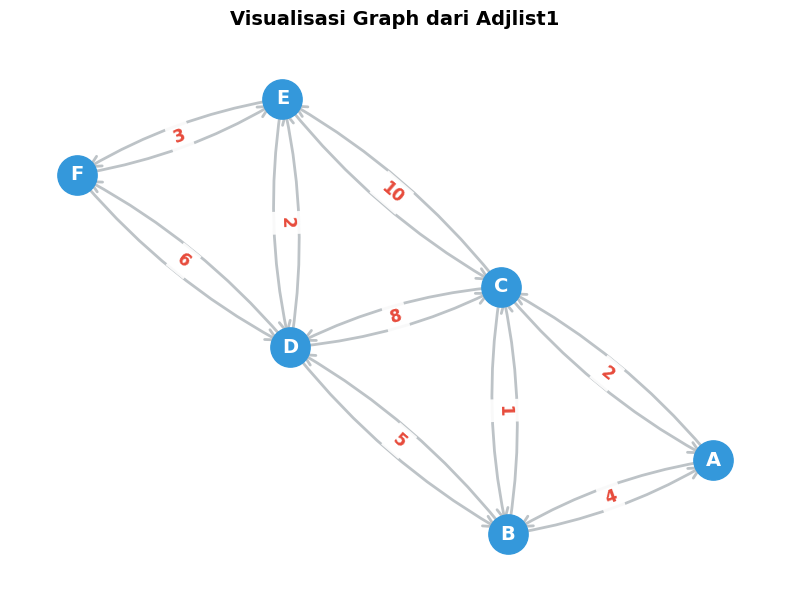

In [ ]:
# G = nx.Graph(adjlist2)          # Untuk Graph Biasa
G = nx.DiGraph(adjlist2)        # Untuk Graph Berarah

pos = nx.spring_layout(G, seed=42)                # Cara Kerjanya Menjauhkan Node yang Tidak Terhubung dan Mendekatkan Node yang terhubung, Hasil Dapat Berbeda2 Setiap Waktu, Maka dari itu digunakanlah seed
# pos = nx.kamada_kawai_layout(G, weight="Jarak")   # Posisi Berorientasi Dengan Atribut / weight
# pos = nx.shell_layout(G)                          # Membuat Graph Melingkar, Dapat Berlaopis
# pos = nx.spiral_layout(G)                         # Membuat Graph Berbentuk Spriral
# pos = nx.planar_layout(G)                         # Edge Tidak Bertabrakan (Namun jika tidak bisa, akan error)
# pos = nx.circular_layout(G)                       # Membuat Graph Melingkar, Tidak Dapat Berlapis
# pos = graphviz_layout(G, prog="dot")              # Khusus Untuk Tree (Tapi Download Graphviz Dulu)

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='#3498db')
nx.draw_networkx_edges(
    G, pos, 
    width=2, 
    edge_color='#bdc3c7'
    , arrowsize=20,                 # untuk setting ukuran ujung edge
    arrowstyle='->',                # untuk setting style ujung edge
    connectionstyle='arc3,rad=0.1'  # untuk setting style garis
)
# NB : Jika ini menggunakan nx.Graph, arrowsize,arrowstyle,dan connectionstyle tidak akan berpengaruh

nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', font_color='white')   # Untuk menuliskan nama Node

edge_labels = nx.get_edge_attributes(G, 'Jarak')    # Tambahkan ini jika edge mempunyai atribut
nx.draw_networkx_edge_labels(                       # Penulisan Atribut
    G, pos, 
    edge_labels=edge_labels, 
    font_size=12, 
    font_color='#e74c3c', 
    font_weight='bold',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7) # Efek kotak putih di belakang angka agar terbaca
)
plt.title("Visualisasi Graph dari Adjlist1", fontsize=14, fontweight='bold', pad=20)
plt.axis('off')     # Menghilangkan Garis Tepi
plt.tight_layout()
plt.show()